# Speech Emotion Recognition Pipeline (RAVDESS + CREMA-D + TESS)

> Unified target labels: **happy, sad, angry, neutral**

This notebook builds a complete end-to-end pipeline with:
- automatic dataset scanning and analysis
- label standardization across datasets
- consistent preprocessing (22050 Hz, 3s, mono, normalized)
- feature extraction (MFCC + Chroma + Mel)
- train-only augmentation (noise + time shift)
- stratified split, training, evaluation, bias checks
- reusable prediction functions for files and microphone input

In [1]:
# If needed, uncomment and run:
# %pip install -q librosa soundfile sounddevice seaborn scikit-learn

import warnings
from pathlib import Path
from collections import Counter
import random

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
 )

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)
random.seed(42)

PROJECT_ROOT = Path.cwd()
TARGET_SR = 22050
TARGET_DURATION = 3.0
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)
UNIFIED_LABELS = ["happy", "sad", "angry", "neutral"]

print(f"Project root: {PROJECT_ROOT}")
print(f"Target audio format: {TARGET_SR} Hz, {TARGET_DURATION}s, mono")

Project root: d:\third sem\some experiments\Maulik_proj
Target audio format: 22050 Hz, 3.0s, mono


In [2]:
# -----------------------------
# 1) Dataset scanning + labeling
# -----------------------------

DATASET_PATH_CANDIDATES = {
    "RAVDESS": [
        PROJECT_ROOT / "Audio_Speech_Actors_01-24",
    ],
    "CREMA-D": [
        PROJECT_ROOT / "archive" / "AudioWAV",
        PROJECT_ROOT / "AudioWAV",
    ],
    "TESS": [
        PROJECT_ROOT / "archive (2)" / "TESS Toronto emotional speech set data",
        PROJECT_ROOT / "TESS Toronto emotional speech set data",
    ],
}

RAVDESS_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprise",
}

CREMAD_MAP = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "SAD": "sad",
    "NEU": "neutral",
}

def resolve_dataset_paths(path_candidates):
    resolved = {}
    for dataset, candidates in path_candidates.items():
        found = [p for p in candidates if p.exists() and p.is_dir()]
        resolved[dataset] = found
    return resolved

def parse_ravdess_label(file_path: Path):
    parts = file_path.stem.split("-")
    if len(parts) < 3:
        return None
    return RAVDESS_MAP.get(parts[2])

def parse_cremad_label(file_path: Path):
    parts = file_path.stem.upper().split("_")
    if len(parts) < 3:
        return None
    return CREMAD_MAP.get(parts[2])

def parse_tess_label(file_path: Path):
    stem = file_path.stem.lower()
    tokens = stem.split("_")

    # Typical TESS names: OAF_word_angry / YAF_word_happy
    if len(tokens) >= 2:
        last = tokens[-1]
        if last in {"angry", "happy", "sad", "neutral", "fear", "disgust", "ps", "surprised", "surprise"}:
            if last == "ps":
                return "pleasant_surprise"
            if last in {"surprised", "surprise"}:
                return "surprise"
            return last

    # Fallback: infer from parent folder name (e.g., OAF_angry)
    folder_text = "_".join([p.name.lower() for p in file_path.parents[:3]])
    keywords = [
        "angry", "happy", "sad", "neutral", "fear", "disgust",
        "pleasant_surprise", "surprise", "pleasant-surprised", "pleasant_surprised"
    ]
    for kw in keywords:
        if kw in folder_text:
            if "pleasant" in kw or "surprise" in kw:
                return "surprise"
            return kw

    return None

def parse_label(dataset_name: str, file_path: Path):
    if dataset_name == "RAVDESS":
        return parse_ravdess_label(file_path)
    if dataset_name == "CREMA-D":
        return parse_cremad_label(file_path)
    if dataset_name == "TESS":
        return parse_tess_label(file_path)
    return None

def scan_datasets(dataset_paths):
    rows = []
    seen = set()
    for dataset_name, roots in dataset_paths.items():
        for root in roots:
            for wav_file in root.rglob("*.wav"):
                full_path = wav_file.resolve()
                if full_path in seen:
                    continue
                seen.add(full_path)

                raw_label = parse_label(dataset_name, wav_file)
                rows.append({
                    "dataset": dataset_name,
                    "path": str(full_path),
                    "raw_label": raw_label,
                })
    return pd.DataFrame(rows)

dataset_paths = resolve_dataset_paths(DATASET_PATH_CANDIDATES)
for name, paths in dataset_paths.items():
    print(f"{name}: {[str(p) for p in paths] if paths else 'NOT FOUND'}")

RAVDESS: ['d:\\third sem\\some experiments\\Maulik_proj\\Audio_Speech_Actors_01-24']
CREMA-D: ['d:\\third sem\\some experiments\\Maulik_proj\\archive\\AudioWAV']
TESS: ['d:\\third sem\\some experiments\\Maulik_proj\\archive (2)\\TESS Toronto emotional speech set data']


In [3]:
# -----------------------------
# 2) Dataset analysis
# -----------------------------

def print_distribution(df, title, label_col):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    if df.empty:
        print("No rows available.")
        return

    table = pd.crosstab(df["dataset"], df[label_col], margins=True)
    print(table)

def imbalance_report(df, label_col, group_col="dataset", threshold=1.5):
    print("\nClass imbalance report:")
    for ds, sub in df.groupby(group_col):
        counts = sub[label_col].value_counts()
        if counts.empty:
            print(f"- {ds}: no labels")
            continue
        ratio = counts.max() / max(1, counts.min())
        status = "IMBALANCED" if ratio > threshold else "OK"
        print(f"- {ds}: min={counts.min()}, max={counts.max()}, ratio={ratio:.2f} -> {status}")

metadata_df = scan_datasets(dataset_paths)
print(f"Total discovered audio files: {len(metadata_df)}")
print(f"Rows with unparsed labels: {metadata_df['raw_label'].isna().sum()}")

print_distribution(metadata_df.fillna("UNKNOWN"), "Raw label distribution by dataset", "raw_label")
imbalance_report(metadata_df.dropna(subset=["raw_label"]), label_col="raw_label")

Total discovered audio files: 14482
Rows with unparsed labels: 0

Raw label distribution by dataset
raw_label  angry  calm  disgust  fear  happy  neutral  pleasant_surprise  \
dataset                                                                    
CREMA-D     1271     0     1271  1271   1271     1087                  0   
RAVDESS      192   192      192   192    192       96                  0   
TESS         800     0      800   800    800      800                800   
All         2263   192     2263  2263   2263     1983                800   

raw_label   sad  surprise    All  
dataset                           
CREMA-D    1271         0   7442  
RAVDESS     192       192   1440  
TESS        800         0   5600  
All        2263       192  14482  

Class imbalance report:
- CREMA-D: min=1087, max=1271, ratio=1.17 -> OK
- RAVDESS: min=96, max=192, ratio=2.00 -> IMBALANCED
- TESS: min=800, max=800, ratio=1.00 -> OK


In [4]:
# -----------------------------
# 3) Label standardization
# -----------------------------

LABEL_STANDARDIZATION = {
    "happy": "happy",
    "sad": "sad",
    "angry": "angry",
    "neutral": "neutral",
    "calm": "neutral",
}

DROP_EMOTIONS = {"disgust", "surprise", "pleasant_surprise", "fear"}

def standardize_label(raw_label):
    if raw_label is None or (isinstance(raw_label, float) and np.isnan(raw_label)):
        return None
    label = str(raw_label).strip().lower()
    label = label.replace("pleasant-surprised", "pleasant_surprise")
    label = label.replace("pleasant_surprised", "pleasant_surprise")

    if label in DROP_EMOTIONS:
        return None
    return LABEL_STANDARDIZATION.get(label, None)

metadata_df["label"] = metadata_df["raw_label"].apply(standardize_label)
clean_df = metadata_df.dropna(subset=["label"]).copy()
clean_df = clean_df[clean_df["label"].isin(UNIFIED_LABELS)].copy()

print(f"After standardization/filtering: {len(clean_df)} samples")
print_distribution(clean_df, "Unified label distribution by dataset", "label")
imbalance_report(clean_df, label_col="label")

print("\nDropped rows summary:")
print(f"- Unparsed labels: {metadata_df['raw_label'].isna().sum()}")
print(f"- Removed by mapping/drop rules: {len(metadata_df) - len(clean_df)}")

After standardization/filtering: 8964 samples

Unified label distribution by dataset
label    angry  happy  neutral   sad   All
dataset                                   
CREMA-D   1271   1271     1087  1271  4900
RAVDESS    192    192      288   192   864
TESS       800    800      800   800  3200
All       2263   2263     2175  2263  8964

Class imbalance report:
- CREMA-D: min=1087, max=1271, ratio=1.17 -> OK
- RAVDESS: min=192, max=288, ratio=1.50 -> OK
- TESS: min=800, max=800, ratio=1.00 -> OK

Dropped rows summary:
- Unparsed labels: 0
- Removed by mapping/drop rules: 5518


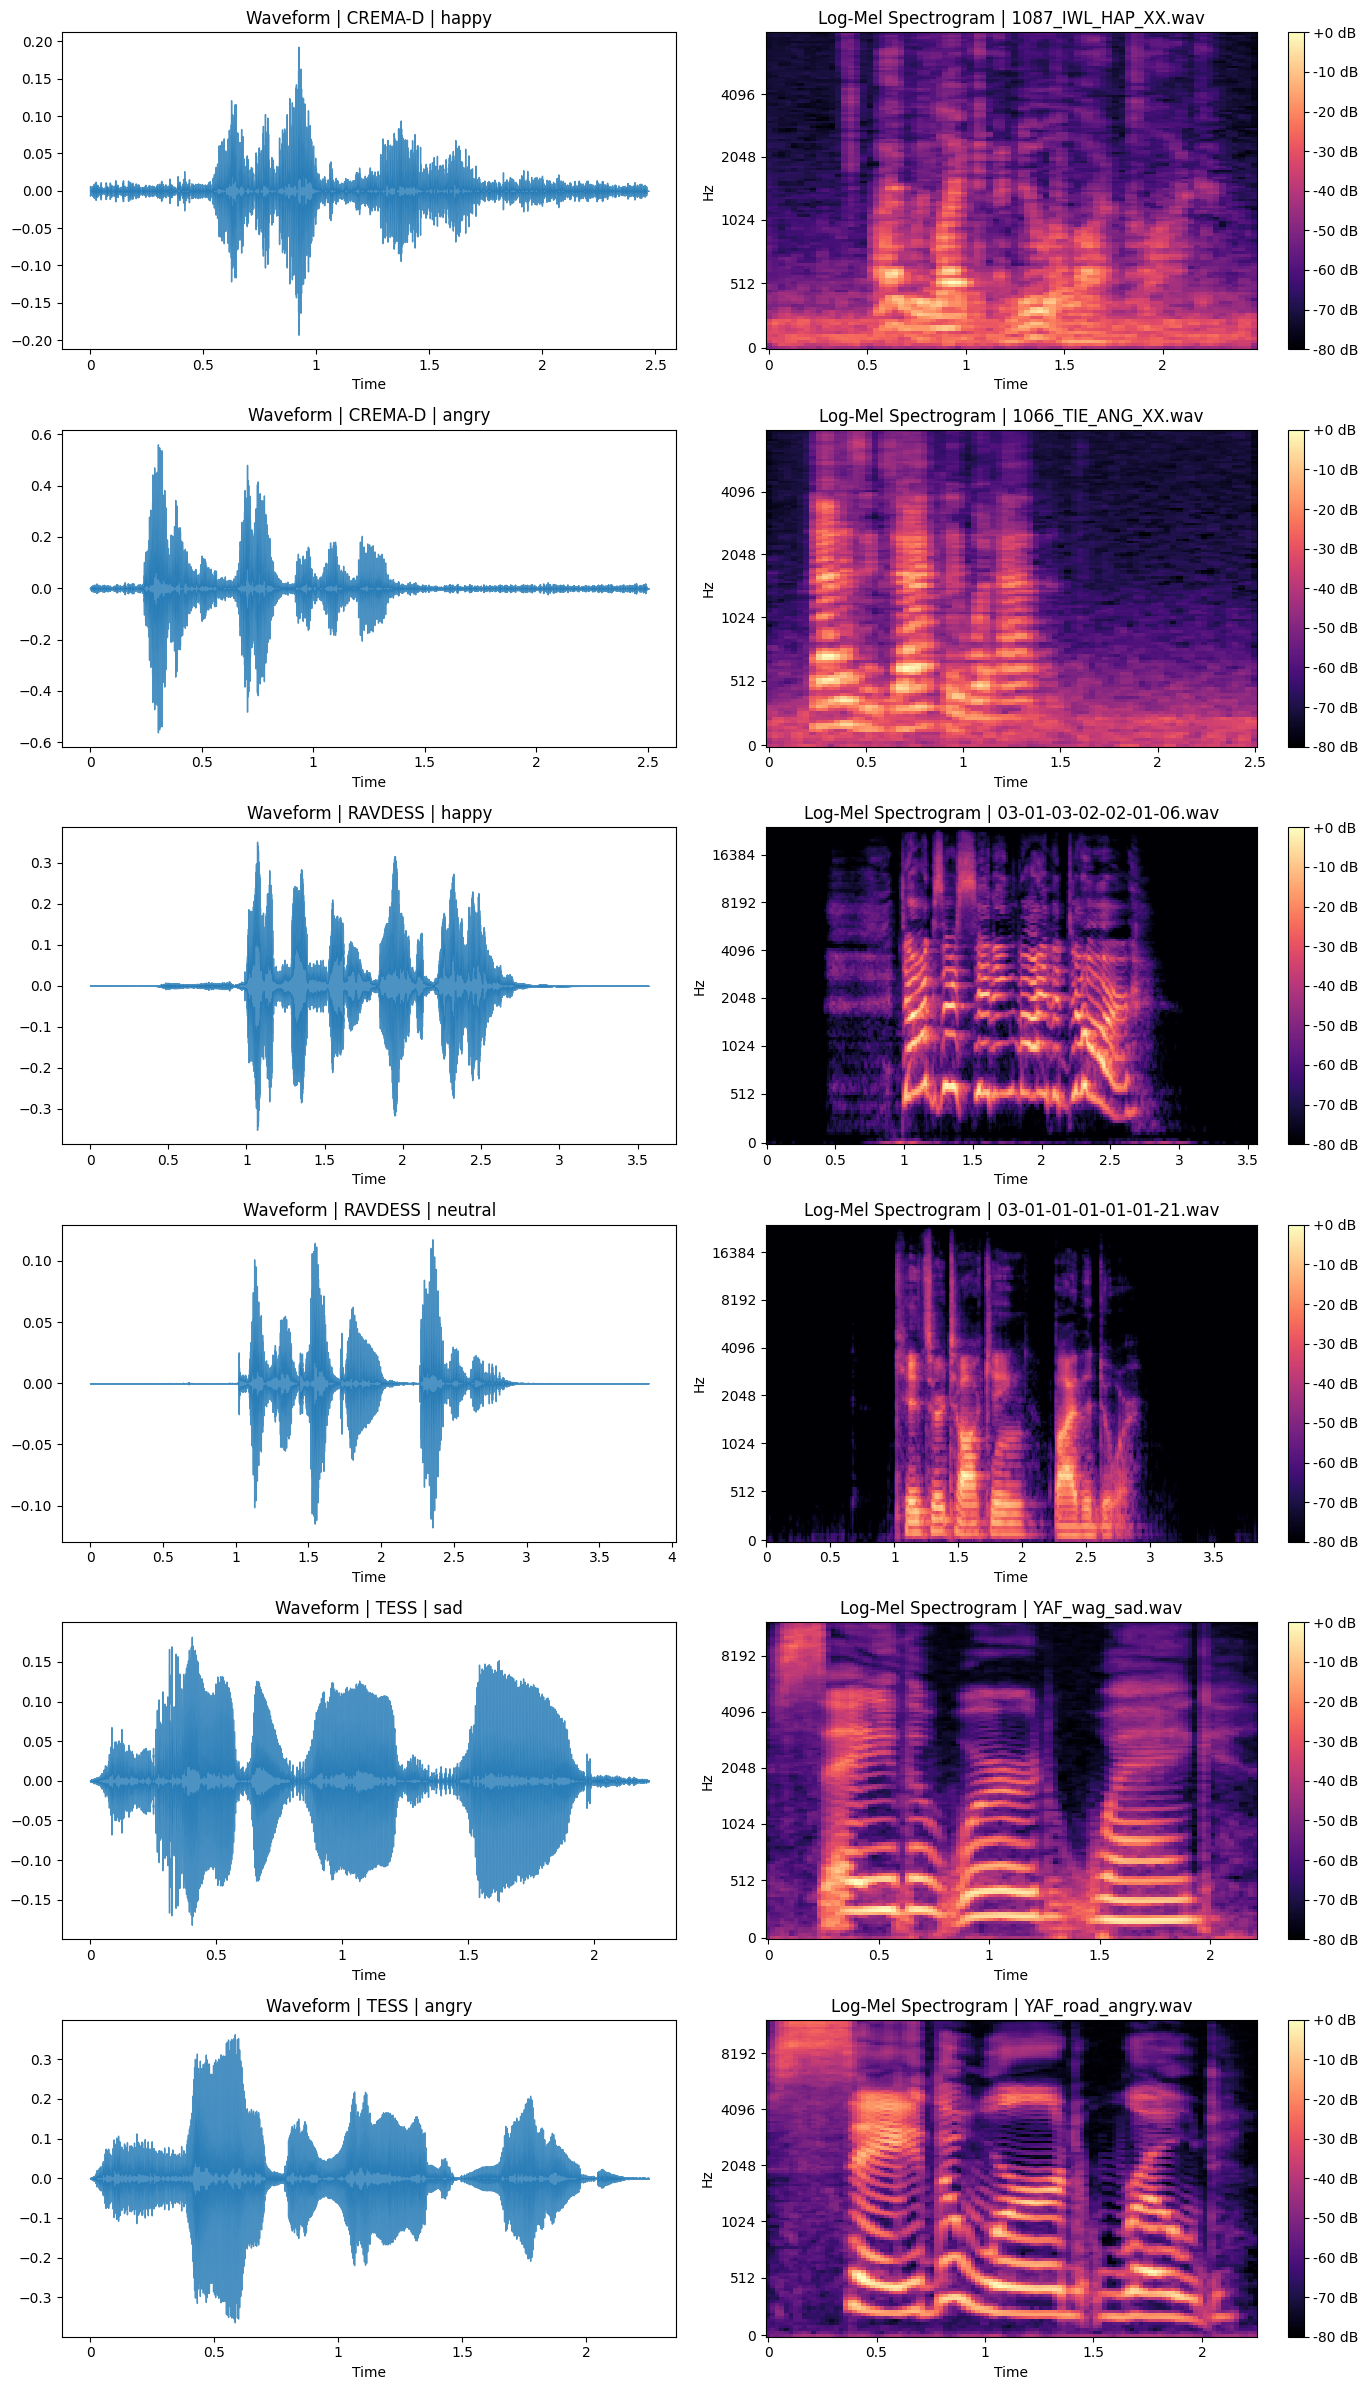

In [5]:
# -----------------------------
# 4) Example waveforms + spectrograms
# -----------------------------

def load_audio_raw(file_path):
    # Keep original SR here for diagnostics/inspection.
    y, sr = librosa.load(file_path, sr=None, mono=True)
    return y, sr

def plot_examples(df, examples_per_dataset=1, random_state=42):
    rows = []
    for ds, sub in df.groupby("dataset"):
        k = min(examples_per_dataset, len(sub))
        sampled = sub.sample(n=k, random_state=random_state)
        rows.extend(sampled.to_dict("records"))

    if not rows:
        print("No examples to plot.")
        return

    fig, axes = plt.subplots(len(rows), 2, figsize=(14, 4 * len(rows)))
    if len(rows) == 1:
        axes = np.array([axes])

    for i, row in enumerate(rows):
        y, sr = load_audio_raw(row["path"])

        # Waveform
        librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], alpha=0.8)
        axes[i, 0].set_title(f"Waveform | {row['dataset']} | {row['label']}")

        # Log-mel spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(log_mel, sr=sr, x_axis="time", y_axis="mel", ax=axes[i, 1])
        axes[i, 1].set_title(f"Log-Mel Spectrogram | {Path(row['path']).name}")
        fig.colorbar(img, ax=axes[i, 1], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

plot_examples(clean_df, examples_per_dataset=2)

In [6]:
# -----------------------------
# 5) Preprocessing + feature extraction + augmentation
# -----------------------------

def pad_or_trim(y, target_length=TARGET_SAMPLES):
    if len(y) > target_length:
        return y[:target_length]
    if len(y) < target_length:
        return np.pad(y, (0, target_length - len(y)))
    return y

def preprocess_audio(file_path, target_sr=TARGET_SR, target_duration=TARGET_DURATION, normalize=True, warn=True):
    y_raw, sr_raw = librosa.load(file_path, sr=None, mono=True)
    duration_raw = len(y_raw) / float(sr_raw) if sr_raw else 0.0

    warning_msgs = []
    if sr_raw != target_sr:
        warning_msgs.append(f"SR mismatch: {sr_raw} -> {target_sr}")
    if abs(duration_raw - target_duration) > 0.05:
        warning_msgs.append(f"Duration mismatch: {duration_raw:.2f}s -> {target_duration:.2f}s")

    # Resample to target sample rate, enforce mono, then fixed-length pad/trim.
    y = librosa.resample(y_raw, orig_sr=sr_raw, target_sr=target_sr) if sr_raw != target_sr else y_raw
    y = pad_or_trim(y, target_length=int(target_sr * target_duration))

    if normalize:
        peak = np.max(np.abs(y))
        if peak > 0:
            y = y / peak

    if warn and warning_msgs:
        warnings.warn(f"{Path(file_path).name}: " + " | ".join(warning_msgs))

    meta = {
        "original_sr": sr_raw,
        "original_duration": duration_raw,
        "target_sr": target_sr,
        "target_duration": target_duration,
        "num_samples": len(y),
        "warnings": warning_msgs,
    }
    return y.astype(np.float32), meta

def extract_feature_vector(y, sr=TARGET_SR, n_mfcc=40, n_mels=128):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Mean + std pooling gives a fixed vector size for variable frame counts.
    features = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(chroma, axis=1), np.std(chroma, axis=1),
        np.mean(mel_db, axis=1), np.std(mel_db, axis=1),
    ])

    return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

def add_noise(y, noise_factor=0.003):
    noise = np.random.normal(0, 1, len(y)).astype(np.float32)
    y_aug = y + noise_factor * noise
    return np.clip(y_aug, -1.0, 1.0)

def time_shift(y, max_shift_pct=0.10):
    max_shift = int(len(y) * max_shift_pct)
    if max_shift <= 1:
        return y
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(y, shift)

def build_features_from_df(df, augment=False):
    X, y, meta_rows = [], [], []
    failed = 0

    for row in df.itertuples(index=False):
        try:
            y_sig, meta = preprocess_audio(row.path, warn=False)
            x = extract_feature_vector(y_sig)

            X.append(x)
            y.append(row.label)
            meta_rows.append({"path": row.path, "dataset": row.dataset, "aug": "original", **meta})

            if augment:
                y_noise = add_noise(y_sig)
                X.append(extract_feature_vector(y_noise))
                y.append(row.label)
                meta_rows.append({"path": row.path, "dataset": row.dataset, "aug": "noise"})

                y_shift = time_shift(y_sig)
                X.append(extract_feature_vector(y_shift))
                y.append(row.label)
                meta_rows.append({"path": row.path, "dataset": row.dataset, "aug": "shift"})
        except Exception:
            failed += 1

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    meta_df = pd.DataFrame(meta_rows)
    print(f"Feature extraction complete. Success={len(X)}, Failed={failed}, Augment={augment}")
    return X, y, meta_df

In [7]:
# -----------------------------
# 6) Combine datasets + stratified split + encoding
# -----------------------------

combined_df = clean_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
print(f"Combined cleaned dataset size: {len(combined_df)}")

train_df, test_df = train_test_split(
    combined_df,
    test_size=0.20,
    random_state=42,
    stratify=combined_df["label"],
)

print(f"Train samples (before augmentation): {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())

label_encoder = LabelEncoder()
label_encoder.fit(UNIFIED_LABELS)

X_train, y_train_text, train_meta = build_features_from_df(train_df, augment=True)
X_test, y_test_text, test_meta = build_features_from_df(test_df, augment=False)

y_train = label_encoder.transform(y_train_text)
y_test = label_encoder.transform(y_test_text)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Class order: {list(label_encoder.classes_)}")

Combined cleaned dataset size: 8964
Train samples (before augmentation): 7171
Test samples: 1793
Train label distribution:
label
angry      1811
happy      1810
sad        1810
neutral    1740
Name: count, dtype: int64

Test label distribution:
label
happy      453
sad        453
angry      452
neutral    435
Name: count, dtype: int64
Feature extraction complete. Success=21513, Failed=0, Augment=True
Feature extraction complete. Success=1793, Failed=0, Augment=False
X_train shape: (21513, 360), y_train shape: (21513,)
X_test shape: (1793, 360), y_test shape: (1793,)
Class order: [np.str_('angry'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


Imbalance ratio (train): 1.04
Using balanced sample weights: False
Iteration 1, loss = 0.57854537
Validation score: 0.771375
Iteration 2, loss = 0.44613109
Validation score: 0.813662
Iteration 3, loss = 0.38879740
Validation score: 0.821561
Iteration 4, loss = 0.34977222
Validation score: 0.859665
Iteration 5, loss = 0.30905251
Validation score: 0.849907
Iteration 6, loss = 0.27733216
Validation score: 0.850372
Iteration 7, loss = 0.23744073
Validation score: 0.876859
Iteration 8, loss = 0.21393594
Validation score: 0.882900
Iteration 9, loss = 0.18833317
Validation score: 0.903346
Iteration 10, loss = 0.16399451
Validation score: 0.873141
Iteration 11, loss = 0.15238067
Validation score: 0.903810
Iteration 12, loss = 0.12548832
Validation score: 0.907063
Iteration 13, loss = 0.11656247
Validation score: 0.916357
Iteration 14, loss = 0.10216662
Validation score: 0.920539
Iteration 15, loss = 0.08779307
Validation score: 0.930297
Iteration 16, loss = 0.09430789
Validation score: 0.91124

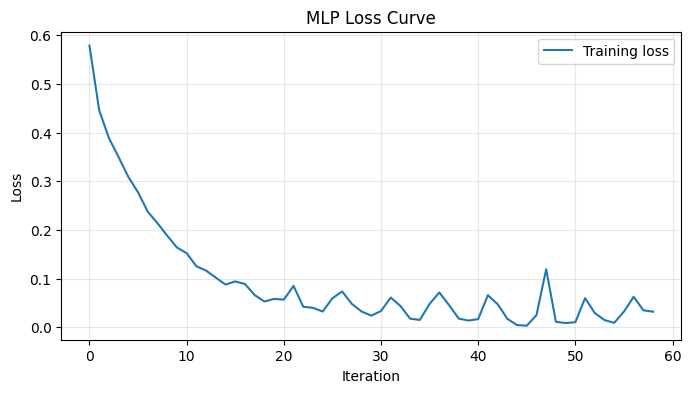

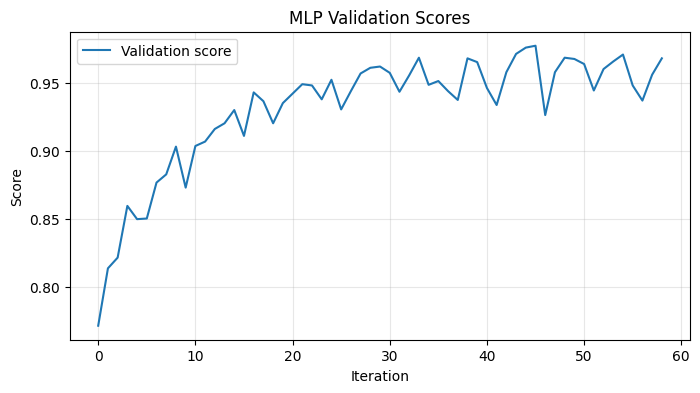

In [8]:
# -----------------------------
# 7) Model building + training (MLP baseline)
# -----------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Detect imbalance on original (non-augmented) train split.
train_counts = train_df["label"].value_counts()
imbalance_ratio = train_counts.max() / max(1, train_counts.min())
use_balanced_weights = imbalance_ratio > 1.5
sample_weight = compute_sample_weight("balanced", y_train) if use_balanced_weights else None

print(f"Imbalance ratio (train): {imbalance_ratio:.2f}")
print(f"Using balanced sample weights: {use_balanced_weights}")

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=120,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=12,
    random_state=42,
    verbose=True,
 )

mlp.fit(X_train_scaled, y_train, sample_weight=sample_weight)
print("Training complete.")
print(f"Iterations: {mlp.n_iter_}")
print(f"Final loss: {mlp.loss_:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label="Training loss")
plt.title("MLP Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
    plt.figure(figsize=(8, 4))
    plt.plot(mlp.validation_scores_, label="Validation score")
    plt.title("MLP Validation Scores")
    plt.xlabel("Iteration")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

Accuracy : 0.8221
Precision: 0.8223
Recall   : 0.8221
F1-score : 0.8218

Classification Report:
              precision    recall  f1-score   support

       angry       0.86      0.88      0.87       452
       happy       0.82      0.77      0.79       453
     neutral       0.78      0.81      0.80       435
         sad       0.83      0.83      0.83       453

    accuracy                           0.82      1793
   macro avg       0.82      0.82      0.82      1793
weighted avg       0.82      0.82      0.82      1793



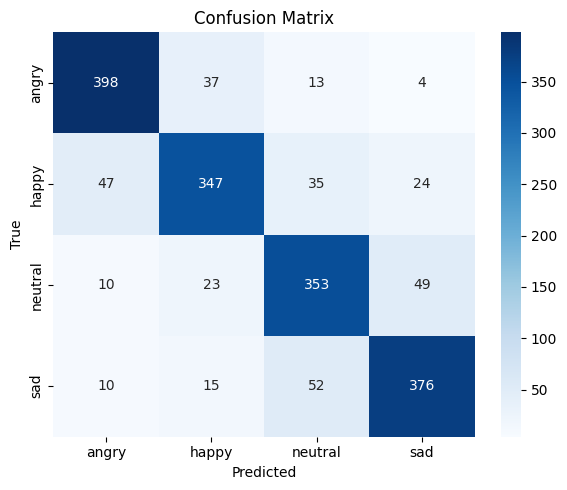


Prediction bias diagnostics:
         true_ratio  pred_ratio  over_prediction
neutral    0.242610    0.252649         0.010039
angry      0.252091    0.259342         0.007250
sad        0.252649    0.252649         0.000000
happy      0.252649    0.235360        -0.017289

No extreme one-class dominance detected from prediction ratios.


In [9]:
# -----------------------------
# 8) Evaluation + bias checks
# -----------------------------

y_pred = mlp.predict(X_test_scaled)
y_proba = mlp.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Simple bias diagnostics
true_counts = pd.Series(label_encoder.inverse_transform(y_test)).value_counts(normalize=True)
pred_counts = pd.Series(label_encoder.inverse_transform(y_pred)).value_counts(normalize=True)

bias_df = pd.DataFrame({
    "true_ratio": true_counts,
    "pred_ratio": pred_counts,
}).fillna(0.0)
bias_df["over_prediction"] = bias_df["pred_ratio"] - bias_df["true_ratio"]
print("\nPrediction bias diagnostics:")
print(bias_df.sort_values("over_prediction", ascending=False))

dominant_pred_ratio = pred_counts.max() if len(pred_counts) else 0
if dominant_pred_ratio > 0.55:
    print("\nWarning: Model appears biased toward one class (high dominant prediction ratio).")
else:
    print("\nNo extreme one-class dominance detected from prediction ratios.")

In [10]:
# -----------------------------
# 9) Inference utilities + consistency/safety checks
# -----------------------------

def transform_audio_to_model_input(audio_file, scaler_obj):
    # Centralized path used by BOTH training-derived inference and predict_emotion.
    y_sig, meta = preprocess_audio(audio_file, warn=True)
    feat = extract_feature_vector(y_sig).reshape(1, -1)
    feat_scaled = scaler_obj.transform(feat)
    return feat_scaled, meta

def predict_emotion(audio_file, model_obj=mlp, scaler_obj=scaler, encoder_obj=label_encoder):
    X_infer, meta = transform_audio_to_model_input(audio_file, scaler_obj)
    probs = model_obj.predict_proba(X_infer)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = encoder_obj.inverse_transform([pred_idx])[0]

    prob_dict = {
        cls: float(prob)
        for cls, prob in zip(encoder_obj.classes_, probs)
    }

    return {
        "audio_file": str(audio_file),
        "predicted_emotion": pred_label,
        "probabilities": prob_dict,
        "preprocess_meta": meta,
    }

def record_microphone(seconds=3.0, sample_rate=TARGET_SR, out_file="mic_input.wav"):
    try:
        import sounddevice as sd
        import soundfile as sf
    except ImportError as exc:
        raise ImportError(
            "Microphone prediction requires sounddevice and soundfile. "
            "Install with: pip install sounddevice soundfile"
        ) from exc

    print(f"Recording {seconds:.1f}s audio from microphone...")
    audio = sd.rec(int(seconds * sample_rate), samplerate=sample_rate, channels=1, dtype="float32")
    sd.wait()
    sf.write(out_file, audio, sample_rate)
    print(f"Saved microphone audio to: {out_file}")
    return out_file

def predict_from_microphone(seconds=3.0):
    mic_file = record_microphone(seconds=seconds)
    result = predict_emotion(mic_file)
    return result

# Quick consistency smoke-check on one known file from test split
sample_audio = test_df.iloc[0]["path"]
sample_result = predict_emotion(sample_audio)
print("Sample prediction:")
print(sample_result)

Sample prediction:
{'audio_file': 'D:\\third sem\\some experiments\\Maulik_proj\\archive\\AudioWAV\\1068_IWW_ANG_XX.wav', 'predicted_emotion': np.str_('angry'), 'probabilities': {np.str_('angry'): 0.9999964237213135, np.str_('happy'): 3.557497393558151e-06, np.str_('neutral'): 1.446284975994107e-18, np.str_('sad'): 3.8469504622346353e-26}, 'preprocess_meta': {'original_sr': 16000, 'original_duration': 1.93525, 'target_sr': 22050, 'target_duration': 3.0, 'num_samples': 66150, 'warnings': ['SR mismatch: 16000 -> 22050', 'Duration mismatch: 1.94s -> 3.00s']}}


In [11]:
# -----------------------------
# 10) Export trained model bundle
# -----------------------------

import joblib
import json
from datetime import datetime

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_bundle = {
    "model": mlp,
    "scaler": scaler,
    "label_encoder": label_encoder,
    "target_sr": TARGET_SR,
    "target_duration": TARGET_DURATION,
    "target_samples": TARGET_SAMPLES,
    "feature_spec": {"mfcc": 40, "use_chroma": True, "use_mel": True},
    "classes": list(label_encoder.classes_),
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

model_path = MODEL_DIR / "ser_mlp_pipeline.joblib"
joblib.dump(model_bundle, model_path)

metrics_snapshot = {
    "accuracy": float(acc),
    "precision_weighted": float(prec),
    "recall_weighted": float(rec),
    "f1_weighted": float(f1),
    "classes": list(label_encoder.classes_),
    "test_size": int(len(y_test)),
}
metrics_path = MODEL_DIR / "ser_test_metrics.json"
metrics_path.write_text(json.dumps(metrics_snapshot, indent=2))

print(f"Model exported to: {model_path}")
print(f"Metrics exported to: {metrics_path}")

Model exported to: d:\third sem\some experiments\Maulik_proj\models\ser_mlp_pipeline.joblib
Metrics exported to: d:\third sem\some experiments\Maulik_proj\models\ser_test_metrics.json


In [12]:
# -----------------------------
# 10) Optional: Run prediction on your own audio file
# -----------------------------

# Example usage:
# user_audio = PROJECT_ROOT / "your_audio.wav"
# result = predict_emotion(user_audio)
# print(result)

# Optional microphone usage:
# mic_result = predict_from_microphone(seconds=3.0)
# print(mic_result)

## Run Order
1. Run cells from top to bottom.
2. Inspect dataset and imbalance reports before training.
3. Verify that only the 4 unified labels remain.
4. Train the model and inspect confusion matrix + bias diagnostics.
5. Use `predict_emotion(audio_file)` for inference.

## Notes
- Augmentation is applied only to training data.
- Preprocessing is centralized in `preprocess_audio` and reused in prediction.
- Non-target emotions (disgust, surprise, fear) are dropped to keep consistent labels.